In [192]:
# Ezinne Akabueze, CMOR 220, Spring 2026, Project 9: Shape Curve Analysis
# Project 9- Shape Curve Analysis.ipynb
# This coding program is tasked to XXXXXX
# Last modified: 4/21/26

In [193]:
import numpy as np
import matplotlib.pyplot as plt

# Defining all necessary functions
def generate_curves(n): # this fucntion creates n number of curves
    # Inputs: n (number of curves we want to generate)

    # set the x values and make an empty matrix that will be filled with x/y values. then set th angle and rotation matricies 
    x = np.arange(0,np.pi+0.02, 0.02) 
    curves = np.zeros((2, len(x), 4 * n)) 
    angle = np.pi/6
    rotation = np. array([[np.cos(angle),-np.sin(angle)],[np.sin(angle),np.cos(angle)]]) # rotation matrix to rotate the curves by 30 degrees
    for i in range(n):
        rot = np.linalg.matrix_power(rotation, i) # rotate the curves by 30 degrees for each cluster
        # generate 4 different clusers: sin, cos, x**2. and abs(x)
        curves[:,:,i] = (rot @ np.array([x, np.cos(x) * i])) + i 
        curves[:,:,i + n] = (rot @ np.array([x, np.sin(x) * i])) + i
        curves[:,:,i+2*n] = (rot @ np.array([x, (x**2) * i])) + i 
        curves[:,:,i+3*n] = (rot @ np.array([x, np.abs(x) * i])) + i 
    return curves # Output: curves (a 3D shape array that has x and y coordinates for each curve)

def preprocess(curve): # this function takes a single curve and prprocesses it by centering it at 0 and normalizing the values using Frobenius norm
    # Inputs: curve (a 2D array with x and y coordinates for a single curve)
    # 1) center at 0, so subtract the mean (use np.mean(..., axis=1, keepdims=True)
    center = np.mean(curve, axis=1, keepdims=True) 
    centcurve = curve - center 
    #2) make Frobenius norm 1 (use np.linalg.norm(..., 'fro') to get the Frobenius norm, and then divide the curve by that value)
    frobenius_norm = np.linalg.norm(centcurve, 'fro')
    newcurve = centcurve / frobenius_norm 
    return newcurve # Output: newcurve (a 2D array with the same shape as the initial curve we inputted, but now with the x and y values normalized to be between 0 and 1)

def distance(curve1, curve2): # this function takes in two curves (already prprocesses) and calculates the distance between them
    # Inputs: curve1 and curve2 (both are 2D arrays with x and y coordinates for a single curve, each already preprocessed using the preprocess function)
    # preprocess both curves
    C1 = preprocess(curve1) 
    C2 = preprocess(curve2) 
    
    #create the A matrix and generate O to eventually get the distance between the two curves
    A = C1 @ C2.T
    U, S, Vh = np.linalg.svd(A) 
    UVh = U @ Vh

    # use if/else to see whether we should or shouldn't use a transformation on O
    if np.linalg.det(UVh) < 0 or np.linalg.det(UVh) == 0:
        O = U @ np.array([[1,0],[0,-1]]) @ Vh
    else:
        O = U @ Vh

    # calculate the distance between the curves
    distance_values = np.linalg.norm(C1-O @ C2, 'fro') # calculate the distance between the two curves
    return distance_values # Output: distance (a single value that represents the distance between the two curves)

def pairwise_distance(curves): # this function takes in a set of curves and calculates the pairwise distance between each curve, returning a distance matrix
    # Inputs: curves (a 3D array with x and y coordinates for each curve, where the shape is (2, number of x values, number of curves))
    
    # figure out the nuber of curves, then use a look to calculate the distance and put it into the distance matrix
    _, _, p = np.shape(curves) 
    distances = np.zeros((p, p)) 
    for i in range(p):
        for j in range(p):
            distances[i, j] = distance(curves[:,:,i], curves[:,:,j]) # calculate the distance between curve i and curve j using the distance function, and then put that value in the distance matrix
    return distances # Output: distance (a matrix that shows the distance between each curve, where the shape is (number of curves, number of curves))

def classify(curve, training):
    # Inputs: curve (a 2D array with x and y coordinates for a single curve, already preprocessed), training (a 3D array with x and y coordinates for each curve in the training set)
    
    # get the number of training curves, then use a look to see the distance between the curve/the training curve, eventually putting the values into a matrix
    _,_, p = np.shape(training) 
    distances = np.zeros(p) 
    for i in range(p):
        distances[i] = distance(curve, training[:,:,i])

    mincurve = np.argmin(distances)
    label = np.ceil((mincurve+1)/10) # determine the label of the closest curve by dividing the index by the number of curves in each cluster (p/4) and then using np.ceil to round up to the nearest whole number
    return label # Output: label (a single value that represents the predicted label of the input curve, based on which curve in the training set it is closest to)

In [194]:
# Part 1: Generate training data/test curves
print("Part 1:")
tr = 10 # training curves/cluster
te = 25 # testing cuves
train_curves = generate_curves(tr) #generate the training curves using the generate_curves
test_curves = generate_curves(te) # generate the testing curves using the generate_curves


Part 1:


Part 2:


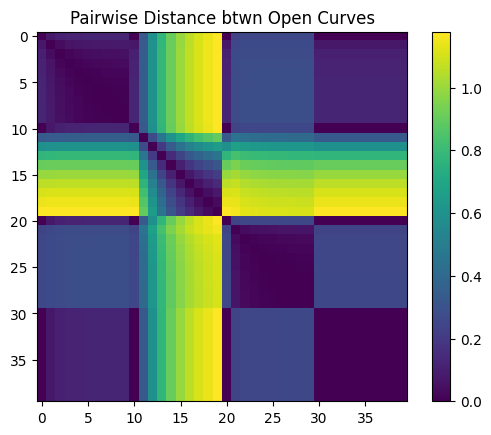

In [195]:
# Part 2: Generate hte curves then visualize the distance matrix w color
print("Part 2:")
pdist = pairwise_distance(train_curves) # calculate the distance matrix for the training curves using the pairwise_distance function
plt.imshow(pdist)
plt.colorbar()
plt.title("Pairwise Distance btwn Open Curves")
plt.show()

In [196]:
# Part 3: classify test curve/accuracy test
print("Part 3:")
tot_tests = te * 4 # total number of test curves (number of clusters * number of curves/cluster)
results = np.zeros(tot_tests) # empty matrix that will hold the predicted labels for each test curve
for i in range(tot_tests):
    results[i] = classify(test_curves[:,:,i], train_curves) # classify each test curve 
real_vals = np.concatenate([np.ones(te), np.ones(te)*2, np.ones(te)*3, np.ones(te)*4]) # create an array with the actual labels for each test curve
classification = np.sum(results==real_vals)
accuracy = (classification/tot_tests)*100 # gets the percentage of correctly classified curves
print("% of correctly classified curves: ", accuracy, "%")
print("The accuracy isn't 100% because due to Python and the way it rounds numbers, the distance values aren't 100% accurate every time, so we see that often leads to a curve not bein classified correctly. To fix the accuracy, implementing things like a range for classifying values or even using a different matrix for distances would help me increase the accuracy of my curves vs the training curves we were given.")

Part 3:
% of correctly classified curves:  92.0 %
The accuracy isn't 100% because due to Python and the way it rounds numbers, the distance values aren't 100% accurate every time, so we see that often leads to a curve not bein classified correctly. To fix the accuracy, implementing things like a range for classifying values or even using a different matrix for distances would help me increase the accuracy of my curves vs the training curves we were given.
